# 3.1. Validation: Gene signatures
# 3.1. 模型验证：基因特征

### 📘 Overview
### 📘 概述

This notebook performs quality control on raw count data to filter out low-quality cells, and then uses DESeq2 to compute differential gene expression signatures (compound vs. DMSO) for each compound.
这个notebook对验证数据的原始计数数据进行质量控制，过滤掉低质量细胞，然后使用DESeq2计算每个化合物的差异基因表达特征（化合物 vs. DMSO对照）。

**Inputs**  
**输入数据**  
Raw gene expression count matrix
原始基因表达计数矩阵（验证数据）

**Output**  
**输出**  
An AnnData file with DESeq2 differential expression results (log₂ fold changes, adjusted p-values)
包含DESeq2差异表达结果的AnnData文件（log₂折叠变化、调整后的p值）  

In [22]:
import numpy as np
import pandas as pd
import anndata as ad

import seaborn as sns
import matplotlib.pyplot as plt

import dilimap as dmap

In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
dmap.logging.print_version()

Running dilimap 0.2.dev20+gc285bd842 (python 3.10.19) on 2025-11-20 01:35.


## Pull raw data
## 拉取原始数据

从S3读取验证数据的原始计数数据。

In [ ]:
adata = dmap.s3.read('validation_data_counts.h5ad', package_name='public/data')
# 从S3读取验证数据的原始计数矩阵

Package: s3://dilimap/public/data. Top hash: 155a2b3b63


In [26]:
from dilimap.utils import platemap

In [ ]:
## Example plate design
## 示例板设计

展示验证数据中实验板的设计布局，包括化合物位置和剂量水平。

adata.obs['WELL_ROW'] = adata.obs['WELL_ID'].str[0]
adata.obs['WELL_COL'] = adata.obs['WELL_ID'].str[1:]

data = adata[adata.obs['PLATE_NAME'] == 'APP1_S1']

CMPD_COLOR = (
    data.obs['COMPOUND']
    .map(
        {
            'DMSO': 'seashell',
            'DMSO_replaced': 'seashell',
            'Chlorpromazine': 'lightsalmon',
        }
    )
    .fillna('lightblue')
)
CMPD_COLOR_OPACITY = '; opacity: ' + data.obs['DOSE_LEVEL'].astype(str).map(
    {'Control': '1', 'Low': '.4', 'Middle': '.6', 'Mid-High': '.8', 'High': '1'}
)


def highlight_cells(x):
    return (
        'background-color: '
        + x.map(dict(zip(data.obs['CMPD_DOSE'], CMPD_COLOR))).fillna('white')
        + x.map(dict(zip(data.obs['CMPD_DOSE'], CMPD_COLOR_OPACITY)))
    )


df_cmpd_map = platemap(data, value_key='CMPD_DOSE', batch='PLATE_NAME')

col_borders = dict(subset=['4', '8'], **{'border-right': '1.5pt solid black'})
row_borders = dict(
    subset=(df_cmpd_map.index.str.endswith(('A', 'D', 'G')), df_cmpd_map.columns),
    **{'border-top': '1.5pt solid black'},
)

display(
    df_cmpd_map.style.apply(highlight_cells)
    .set_properties(**col_borders)
    .set_properties(**row_borders)
)

,1,2,3,4,5,6,7,8,9,10,11,12
APP1_S1_A,Orelabrutinib_High,Orelabrutinib_Mid-High,Orelabrutinib_Middle,Orelabrutinib_Low,Ibrutinib_High,Ibrutinib_Mid-High,Ibrutinib_Middle,Ibrutinib_Low,Remibrutinib_High,Remibrutinib_Mid-High,Remibrutinib_Middle,Remibrutinib_Low
APP1_S1_B,Orelabrutinib_High,Orelabrutinib_Mid-High,Orelabrutinib_Middle,Orelabrutinib_Low,Ibrutinib_High,Ibrutinib_Mid-High,Ibrutinib_Middle,Ibrutinib_Low,Remibrutinib_High,Remibrutinib_Mid-High,Remibrutinib_Middle,Remibrutinib_Low
APP1_S1_C,Orelabrutinib_High,Orelabrutinib_Mid-High,Orelabrutinib_Middle,Orelabrutinib_Low,Ibrutinib_High,Ibrutinib_Mid-High,Ibrutinib_Middle,Ibrutinib_Low,Remibrutinib_High,Remibrutinib_Mid-High,Remibrutinib_Middle,Remibrutinib_Low
APP1_S1_D,Evobrutinib_High,Evobrutinib_Mid-High,Evobrutinib_Middle,Evobrutinib_Low,BMS-986142_High,BMS-986142_Mid-High,BMS-986142_Middle,BMS-986142_Low,Rilzabrutinib_High,Rilzabrutinib_Mid-High,Rilzabrutinib_Middle,Rilzabrutinib_Low
APP1_S1_E,Evobrutinib_High,Evobrutinib_Mid-High,Evobrutinib_Middle,Evobrutinib_Low,BMS-986142_High,BMS-986142_Mid-High,BMS-986142_Middle,BMS-986142_Low,Rilzabrutinib_High,Rilzabrutinib_Mid-High,Rilzabrutinib_Middle,Rilzabrutinib_Low
APP1_S1_F,Evobrutinib_High,Evobrutinib_Mid-High,Evobrutinib_Middle,Evobrutinib_Low,BMS-986142_High,BMS-986142_Mid-High,BMS-986142_Middle,BMS-986142_Low,Rilzabrutinib_High,Rilzabrutinib_Mid-High,Rilzabrutinib_Middle,Rilzabrutinib_Low
APP1_S1_G,DMSO_Control,DMSO_Control,DMSO_Control,DMSO_Control,DMSO_Control,DMSO_Control,DMSO_Control,DMSO_Control,Chlorpromazine_High,Chlorpromazine_High,Chlorpromazine_High,Chlorpromazine_High


## QC (total counts, mtRNA, rRNA)
## 质量控制（总计数、线粒体RNA、核糖体RNA）

对验证数据进行质量控制，检查总RNA计数、线粒体RNA百分比和核糖体RNA百分比。

In [28]:
adata.obs['LDH_QC'].value_counts()

LDH_QC
              763
tech error     12
cell death      5
Name: count, dtype: int64

In [ ]:
adata.obs['ldh_qc_pass'] = adata.obs['LDH_QC'] == ''
# 创建LDH（乳酸脱氢酶）质量控制标志：如果LDH_QC为空字符串，则通过QC

In [ ]:
## QC of total counts and mtRNA
## 总计数和线粒体RNA的质量控制

dmap.pp.qc_metrics(adata)
# 计算质量控制指标：log总RNA、线粒体RNA百分比、核糖体RNA百分比

thresh_counts = (
    np.median(adata.obs['log_totalRNA']) - 2.5 * adata.obs['log_totalRNA'].std()
)
# 计算总RNA阈值：中位数减去2.5倍标准差（用于过滤低质量细胞）
adata.obs['rna_qc_pass'] = (adata.obs['log_totalRNA'] > thresh_counts) & (
    adata.obs['pct_mtRNA'] < 9
)
# 创建RNA质量控制标志：总RNA > 阈值 且 线粒体RNA百分比 < 9%

Added the following to `adata.obs`: ['log_totalRNA', 'pct_mtRNA', 'pct_rRNA']


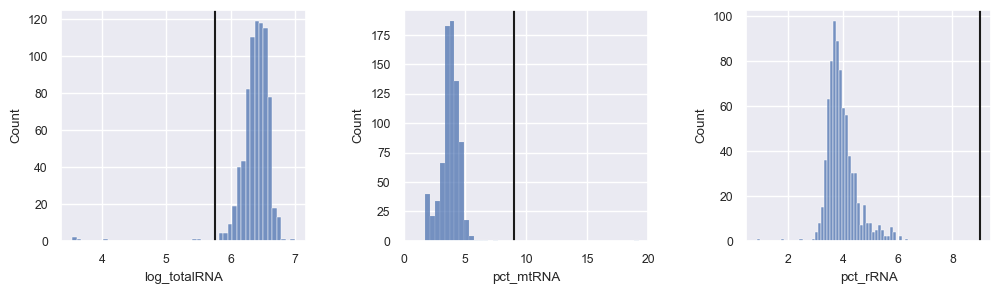

In [31]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3), gridspec_kw={'wspace': 0.4})

sns.histplot(adata.obs['log_totalRNA'], bins=50, ax=axs[0])
sns.histplot(adata.obs['pct_mtRNA'], bins=200, ax=axs[1])
sns.histplot(adata.obs['pct_rRNA'], bins=50, ax=axs[2])

axs[1].set_xlim(0, 20)

axs[0].axvline(thresh_counts, c='k')
axs[1].axvline(9, c='k')
axs[2].axvline(9, c='k')

plt.show()

In [ ]:
## Example plate with QC metrics
## 带有QC指标的示例板

可视化验证数据中单个实验板的QC指标，显示哪些细胞通过了质量控制。

data = adata[adata.obs['PLATE_NAME'] == 'APP1_S1']


def color_boolean(val):
    return f'color: {"lightred" if val else ""}; font-weight: {"bold" if val else ""}'


for val in ['log_totalRNA', 'pct_mtRNA']:
    print(f'\033[1m{val}')

    df = platemap(data, val, batch='PLATE_NAME')
    df_bool = np.invert(platemap(data, 'rna_qc_pass', batch='PLATE_NAME').astype(bool))

    if val != 'notes_flags':
        mu, std = np.median(data.obs[val]), np.std(data.obs[val])

        display(
            df.style.format(precision=2)
            .background_gradient(vmin=mu - 3 * std, vmax=mu + 3 * std, cmap='RdBu_r')
            .apply(lambda c: df_bool[c.name].apply(color_boolean))
            .applymap(lambda x: 'background-color: white' if pd.isnull(x) else '')
            .set_properties(**col_borders)
            .set_properties(**row_borders)
        )

    else:
        display(
            df.style.format(precision=2)
            .apply(lambda c: df_bool[c.name].apply(color_boolean))
            .applymap(lambda x: 'background-color: salmon' if x != '' else '')
            .set_properties(**col_borders)
            .set_properties(**row_borders)
        )

log_totalRNA


/var/folders/fh/r5412d0d6tl262nd_38k08d80000gp/T/ipykernel_56045/820918553.py:23: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: 'background-color: white' if pd.isnull(x) else '')


,1,2,3,4,5,6,7,8,9,10,11,12
APP1_S1_A,6.35,6.40,6.35,6.33,6.27,6.27,6.31,6.31,6.29,6.33,6.21,6.27
APP1_S1_B,6.32,6.43,6.68,6.64,6.59,6.57,6.64,6.61,6.59,6.61,6.60,6.57
APP1_S1_C,6.57,6.57,6.51,6.51,6.47,6.44,6.50,6.52,6.46,6.49,6.40,6.45
APP1_S1_D,6.63,6.73,6.71,6.62,6.54,6.57,6.63,6.60,6.59,6.60,6.55,6.57
APP1_S1_E,6.27,3.68,6.31,6.50,6.54,6.58,6.61,6.53,6.51,6.48,6.52,6.55
APP1_S1_F,6.57,6.61,6.58,6.47,6.39,6.42,6.48,6.46,6.42,6.36,6.34,6.37
APP1_S1_G,6.51,6.55,6.51,6.51,6.45,6.45,6.49,6.48,6.46,6.47,6.45,6.45


pct_mtRNA


/var/folders/fh/r5412d0d6tl262nd_38k08d80000gp/T/ipykernel_56045/820918553.py:23: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: 'background-color: white' if pd.isnull(x) else '')


,1,2,3,4,5,6,7,8,9,10,11,12
APP1_S1_A,3.03,3.66,3.40,3.43,3.15,3.56,3.45,3.03,2.94,3.51,3.23,3.18
APP1_S1_B,3.88,3.55,3.26,3.27,2.95,3.35,3.36,3.07,3.64,3.20,3.18,3.14
APP1_S1_C,3.94,3.69,3.53,3.55,3.08,3.51,3.72,3.26,3.83,3.72,3.68,3.56
APP1_S1_D,2.98,4.92,4.08,4.06,3.10,3.79,3.94,3.73,2.98,3.69,3.56,3.50
APP1_S1_E,5.96,3.86,6.88,3.95,3.54,3.41,3.63,3.61,3.83,3.74,3.25,3.35
APP1_S1_F,4.35,4.58,4.15,4.21,3.74,3.38,3.75,3.42,3.95,3.63,3.32,3.22
APP1_S1_G,3.67,3.60,3.32,3.38,3.54,3.54,3.91,3.34,2.73,2.59,2.70,2.51


## QC (cross-replicate correlation)

In [33]:
dmap.pp.qc_cross_rep_correlation(adata, group_key='CMPD_DOSE', plate_key='PLATE_NAME')

Added the following to `adata.obs`: ['cross_rep_correlation', 'rep_corr_qc_pass']


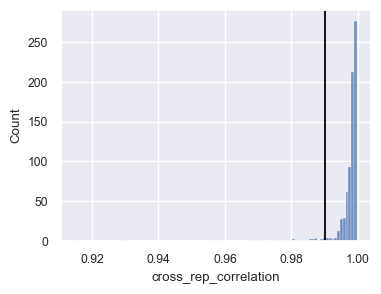

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3), gridspec_kw={'wspace': 0.4})

sns.histplot(
    adata.obs['cross_rep_correlation'][
        adata.obs['ldh_qc_pass'] & adata.obs['rna_qc_pass']
    ],
    bins=100,
    ax=ax,
)
ax.axvline(0.99, c='k')

plt.show()

In [35]:
## Example plate with cross-replicate correlations

data = adata[adata.obs['PLATE_NAME'] == 'APP1_S1']

val = 'cross_rep_correlation'

df = platemap(data, val, batch='PLATE_NAME')
df_bool = np.invert(
    platemap(data, 'rep_corr_qc_pass', batch='PLATE_NAME').fillna(False).astype(bool)
)
mu, std = np.nanmean(data.obs[val]), np.nanstd(data.obs[val])

col_borders = dict(subset=['4', '8'], **{'border-right': '1.5pt solid black'})
row_borders = dict(
    subset=(df.index.str.endswith(('A', 'D', 'G')), df.columns),
    **{'border-top': '1.5pt solid black'},
)

print(val, f'CI=[{mu - 2 * std:0.3f},{1}]')
display(
    df.style.format(precision=3)
    .background_gradient(vmin=mu - 5 * std, vmax=1, cmap='Reds_r')
    .apply(lambda c: df_bool[c.name].apply(color_boolean))
    .applymap(lambda x: 'background-color: white' if pd.isnull(x) else '')
    .set_properties(**col_borders)
    .set_properties(**row_borders)
)

cross_rep_correlation CI=[0.964,1]


/var/folders/fh/r5412d0d6tl262nd_38k08d80000gp/T/ipykernel_56045/2093163877.py:24: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: 'background-color: white' if pd.isnull(x) else '')


,1,2,3,4,5,6,7,8,9,10,11,12
APP1_S1_A,0.929,0.998,0.997,0.998,0.956,0.997,0.997,0.997,0.976,0.997,0.998,0.998
APP1_S1_B,0.999,0.999,0.999,0.998,0.999,0.998,0.996,1.000,0.998,0.998,0.999,0.999
APP1_S1_C,0.999,0.999,0.999,0.998,0.999,0.998,0.997,1.000,0.998,0.998,0.999,0.999
APP1_S1_D,0.915,0.998,0.998,0.998,0.930,0.998,0.997,0.999,0.973,0.999,0.999,0.999
APP1_S1_E,0.994,0.964,0.988,0.998,0.999,0.999,0.997,0.999,0.999,0.999,0.999,0.999
APP1_S1_F,0.994,0.998,0.998,0.998,0.999,0.999,0.997,0.999,0.999,0.999,0.998,0.999
APP1_S1_G,0.998,0.998,0.999,0.999,0.999,0.999,0.999,0.999,0.999,0.999,0.998,0.999


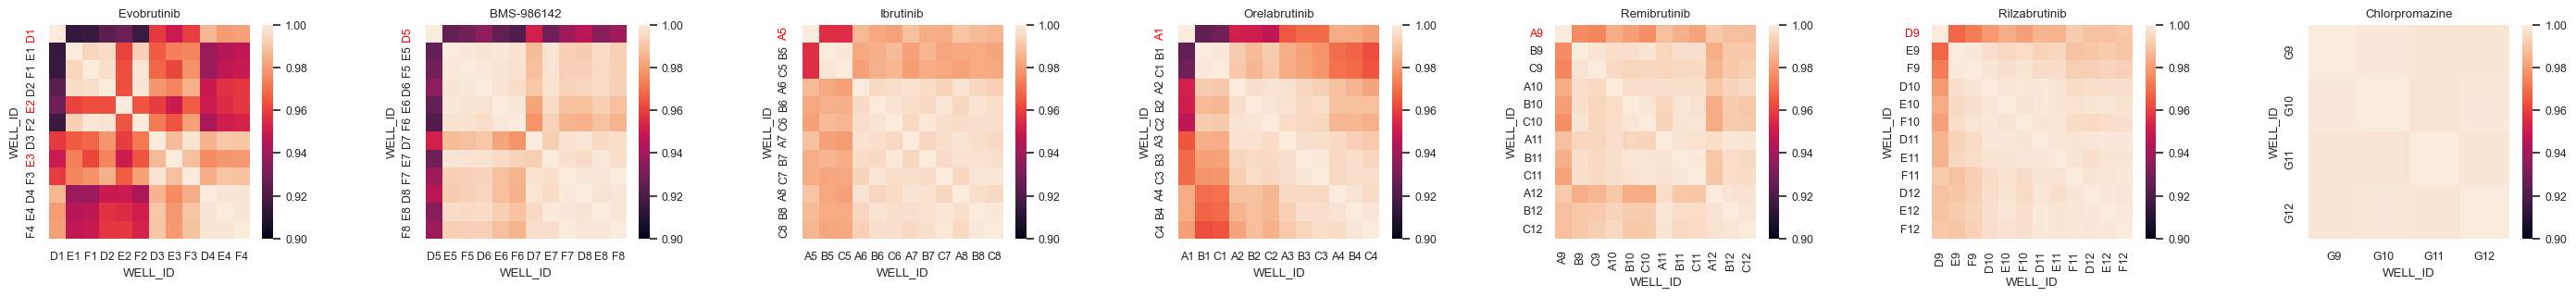

In [36]:
from natsort import index_natsorted

sns.set(font_scale=0.8)

df_cmpd_flags = data.obs[~data.obs['rep_corr_qc_pass']]['COMPOUND'].value_counts()
df_cmpd_flags = df_cmpd_flags[~df_cmpd_flags.index.str.contains('DMSO')]
cmpd_flags = df_cmpd_flags.index[:8]

fig, axs = plt.subplots(
    1, len(cmpd_flags), figsize=(5 * len(cmpd_flags), 3), gridspec_kw={'wspace': 0.5}
)
for i, cmpd_name in enumerate(cmpd_flags):
    df_sub = data[data.obs['COMPOUND'] == cmpd_name].to_df()
    df_sub.index = data[data.obs['COMPOUND'] == cmpd_name].obs['WELL_ID']

    df_sub_corr = df_sub.T.corr()
    idx_sort = index_natsorted(df_sub_corr.index.str[1:] + df_sub_corr.index.str[0])
    df_sub_corr = df_sub_corr.iloc[idx_sort, idx_sort]

    g = sns.heatmap(df_sub_corr, vmax=1, vmin=0.9, yticklabels=True, ax=axs[i])

    flagged = (
        data[(data.obs['COMPOUND'] == cmpd_name) & ~data.obs['rep_corr_qc_pass']]
        .obs['WELL_ID']
        .values
    )
    for label in g.get_yticklabels():
        if label.get_text() in flagged:
            label.set_color('red')

    axs[i].set_title(cmpd_name)

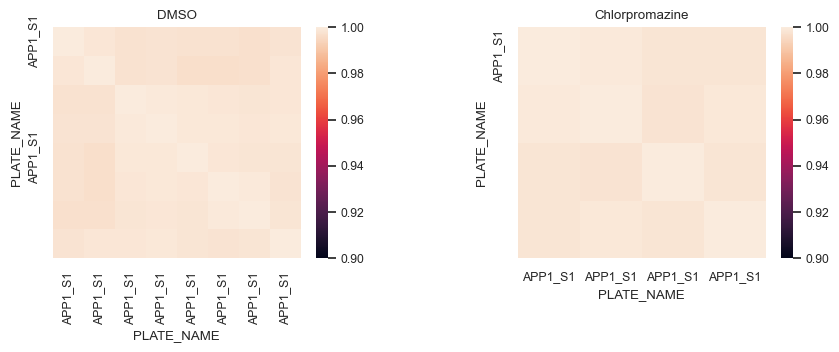

In [37]:
cmpd_flags = ['DMSO', 'Chlorpromazine']

fig, axs = plt.subplots(
    1, len(cmpd_flags), figsize=(5 * len(cmpd_flags), 3), gridspec_kw={'wspace': 0.5}
)
for i, cmpd_name in enumerate(cmpd_flags):
    df_sub = data[data.obs['COMPOUND'] == cmpd_name].to_df()
    df_sub.index = data[data.obs['COMPOUND'] == cmpd_name].obs['PLATE_NAME'].astype(str)

    df_sub_corr = df_sub.T.corr()
    idx_sort = index_natsorted(df_sub_corr.index.str[1:] + df_sub_corr.index.str[0])
    df_sub_corr = df_sub_corr.iloc[idx_sort, idx_sort]

    g = sns.heatmap(df_sub_corr, vmax=1, vmin=0.9, yticklabels=4, ax=axs[i])

    flagged = (
        data[(data.obs['COMPOUND'] == cmpd_name) & ~data.obs['rep_corr_qc_pass']]
        .obs['WELL_ID']
        .values
    )
    for label in g.get_yticklabels():
        if label.get_text() in flagged:
            label.set_color('red')

    axs[i].set_title(cmpd_name)

## QC (hepatocyte fidelity sanity check)

In [38]:
# Log-normalize total counts (similar to sc.pp.normalize_total and sc.pp.log1p)

X = adata.X if isinstance(adata.X, np.ndarray) else adata.X.toarray()
cell_sums = X.sum(axis=1, keepdims=True)
X_norm = (X / cell_sums) * np.median(cell_sums)
X_norm = np.log10(X_norm + 1)

adata_norm = ad.AnnData(X=X_norm, obs=adata.obs, var=adata.var)

/opt/miniconda3/envs/dilimap/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [39]:
# Celltype markers curated from https://panglaodb.se/markers.html and https://pmc.ncbi.nlm.nih.gov/articles/PMC6687507

marker_celltypes = {
    # Hepatocytes, cluster 14 in liver atlas
    'Hepatocytes': [
        'ALB',
        'CYP3A4',
        'APOA1',
        'APOA2',
        'APOC3',
        'TF',
        'APOH',
        'ALDOB',
        'TTR',
        'GSTA2',
    ],
    # Kupffer, from panglaodb
    'Kupffer': ['C1QB', 'C1QA', 'CD163', 'MAFB', 'CSF1R', 'CLEC4F', 'FCNA', 'ADGRE1'],
    # Liver Sinusoidal Endothelial Cells (LSEC), cluster 9 in liver atlas
    'LSEC': ['EGFL7', 'FLT1', 'CLEC4M', 'CLEC4G', 'FCN3', 'STAB1', 'DNASE1L3'],
    # Hepatic Stellate Cells (HSC), from panglaodb
    'HSC': ['IGFBP6', 'COL1A2', 'SPARC', 'TPM2', 'COL3A1', 'MYL9', 'DCN'],
    # Cholangiocyte, cluster 4+7 in liver atlas
    'Cholangiocyte': ['AGR2', 'ELF3', 'CLDN4', 'KRT7', 'AQP1'],  # "KRT19",
    # Dedifferentiation, low in mature, high in dedifferentiated
    'Dedifferentiated': [
        'KRT19',  # Biliary/progenitor marker
        'EPCAM',  # Also indicates epithelial progenitors
        'LAMB1',  # ECM remodeling and stress-induced dedifferentiation
        'PROM1',  # Progenitor/stemness marker
        'LGR5',  # Liver progenitor marker
        'AFP',  # Strongly fetal/hepatoblast marker
    ],
}

all_markers = np.hstack(list(marker_celltypes.values()))
all_markers = [g for g in all_markers if g in adata_norm.var_names]

idx = (
    adata_norm.obs['ldh_qc_pass']
    & adata_norm.obs['rna_qc_pass']
    & adata_norm.obs['rep_corr_qc_pass']
)
marker_expr = adata_norm[
    idx & (adata_norm.obs['COMPOUND'] == 'DMSO'), all_markers
].to_df()

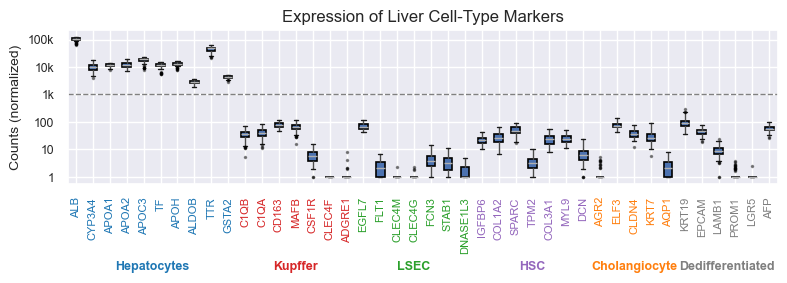

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Color palette
celltype_palette = {
    'Hepatocytes': '#1f77b4',
    'Kupffer': '#d62728',
    'LSEC': '#2ca02c',
    'HSC': '#9467bd',
    'Cholangiocyte': '#ff7f0e',
    'Dedifferentiated': '#7f7f7f',
}

# Flatten mapping: gene → celltype
marker_to_celltype = {g: ct for ct, genes in marker_celltypes.items() for g in genes}
genes = list(marker_expr.columns)
celltypes = [marker_to_celltype.get(g, 'Unknown') for g in genes]

# Plot
fig, ax = plt.subplots(figsize=(8, 3.5))
flierprops = dict(
    marker='o', markersize=1.5, linestyle='none', markerfacecolor='black', alpha=0.4
)
box = marker_expr.boxplot(
    rot=90,
    patch_artist=True,
    flierprops=flierprops,
    boxprops=dict(color='black', linewidth=1.2),
    ax=ax,
)

# Main x-axis: gene names
xticks = np.arange(1, len(genes) + 1)
ax.set_xticks(xticks)
ax.set_xticklabels(genes, rotation=90, fontsize=8)
for label in ax.get_xticklabels():
    gene = label.get_text()
    celltype = marker_to_celltype.get(gene, 'black')
    label.set_color(celltype_palette.get(celltype, 'black'))

# Y-axis: log10(counts) → raw counts
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '10', '100', '1k', '10k', '100k'])

# Horizontal guide
ax.axhline(3, ls='--', lw=1, color='gray')

# Compute midpoints for grouped cell types
unique_blocks = []
start_idx = 0
for i in range(1, len(genes)):
    if celltypes[i] != celltypes[i - 1]:
        mid = (start_idx + i - 1) / 2 + 1
        unique_blocks.append((mid, celltypes[i - 1]))
        start_idx = i
mid = (start_idx + len(genes) - 1) / 2 + 1
unique_blocks.append((mid, celltypes[-1]))

# Add cell type labels below the plot (just below x-axis)
y_pos = -0.5  # adjust as needed
for x, label_text in unique_blocks:
    ax.text(
        x,
        y_pos,
        label_text,
        ha='center',
        va='top',
        fontsize=9,
        fontweight='bold',
        color=celltype_palette.get(label_text, 'black'),
        transform=ax.get_xaxis_transform(),
    )

# Final touches
ax.set_title('Expression of Liver Cell-Type Markers', fontsize=12)
ax.set_ylabel('Counts (normalized)', fontsize=10)
plt.tight_layout()
plt.show()

## DESeq2

In [41]:
%%capture

from dask.distributed import LocalCluster, Client

cluster = LocalCluster(n_workers=8, threads_per_worker=1, memory_limit='auto')
client = Client(cluster)

In [42]:
adatas = {}

for plate in np.unique(adata.obs['PLATE_NAME']):
    adata_batch = adata[adata.obs['PLATE_NAME'] == plate].copy()
    adata_batch = adata_batch[
        adata_norm.obs['ldh_qc_pass']
        & adata_norm.obs['rna_qc_pass']
        & adata_norm.obs['rep_corr_qc_pass']
    ].copy()

    adata_batch.obs_names_make_unique()

    adatas[plate] = dmap.pp.deseq2(
        adata_batch,
        pert_name_col='COMPOUND',
        other_pert_cols=['DOSE_LEVEL'],
        dask_client=client,
    )

    adatas[plate].obs['PLATE_NAME'] = plate

/opt/miniconda3/envs/dilimap/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


IndexError: Boolean index does not match AnnData’s shape along this dimension. Boolean index has shape (780,) while AnnData index has shape (84,).

In [43]:
adata_deseq = ad.concat(adatas.values(), join='outer')

ValueError: No objects to concatenate

In [46]:
np.sum(~np.isnan(adata_deseq.X[~np.all(np.isnan(adata_deseq.X), 1)].sum(0)))

NameError: name 'adata_deseq' is not defined

In [45]:
adata_deseq = adata_deseq[~np.all(np.isnan(adata_deseq.X), 1)].copy()

NameError: name 'adata_deseq' is not defined

## Push file to S3

In [44]:
# dmap.s3.write(adata_deseq, 'validation_data_deseq2.h5ad', package_name='public/data')